In [4]:
!pip install mne
import mne
import numpy as np
import matplotlib.pyplot as plt
from mne.datasets.sleep_physionet.age import fetch_data

L_FREQ=0.5
H_FREQ=30.0
EEG_CHANNELS = ['EEG Fpz-Cz', 'EEG Pz-Oz']

files = fetch_data(subjects=[0], recording=[1])
raw = mne.io.read_raw_edf(files[0][0], preload=True)
annotations = mne.read_annotations(files[0][1])
raw.set_annotations(annotations)

raw_filtered = raw.copy().filter(l_freq=L_FREQ, h_freq=H_FREQ)
raw_filtered.pick(EEG_CHANNELS)

print("complete")

Using default location ~/mne_data for PHYSIONET_SLEEP...
Creating /root/mne_data


  0%|                                              | 0.00/48.3M [00:00<?, ?B/s]

  0%|                                              | 0.00/4.62k [00:00<?, ?B/s]

Download complete in 04m43s (46.1 MB)
Extracting EDF parameters from /root/mne_data/physionet-sleep-data/SC4001E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...


/tmp/ipykernel_583/2615907277.py:12: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(files[0][0], preload=True)
/tmp/ipykernel_583/2615907277.py:12: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(files[0][0], preload=True)
/tmp/ipykernel_583/2615907277.py:12: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(files[0][0], preload=True)


Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...


/tmp/ipykernel_583/2615907277.py:14: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 661 samples (6.610 s)

complete


In [5]:
from mne.preprocessing import ICA

N_COMPONENTS=2
RANDOM_STATE=42

ica=ICA(n_components=N_COMPONENTS,random_state=RANDOM_STATE)
ica.fit(raw_filtered)
print("ICA complete")
print(ica)

Fitting ICA to data using 2 channels (please be patient, this may take a while)
Selecting by number: 2 components
Fitting ICA took 2.9s.
ICA complete
<ICA | raw data decomposition, method: fastica (fit in 3 iterations on 7950000 samples), 2 ICA components (2 PCA components available), channel types: eeg, no sources marked for exclusion>


In [6]:
#ICA成分を可視化
ica.plot_components()
plt.show()

RuntimeError: No digitization points found.

Creating RawArray with float64 data, n_channels=2, n_times=7950000
    Range : 0 ... 7949999 =      0.000 ... 79499.990 secs
Ready.
Using matplotlib as 2D backend.


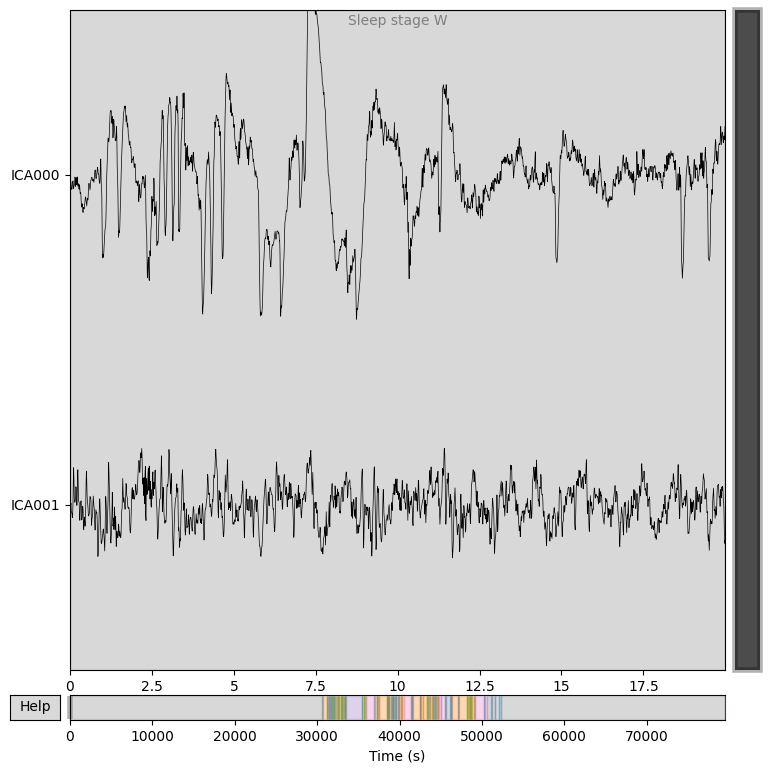

In [8]:
#電極の位置情報が無いから、時系列で可視化する
ica.plot_sources(raw_filtered)
plt.show()

In [9]:
#ICA000をノイズとして除去
ica.exclude=[0]

#除去後のデータ
raw_clean=raw_filtered.copy()
ica.apply(raw_clean)
print("artifact clean complete")

Applying ICA to Raw instance
    Transforming to ICA space (2 components)
    Zeroing out 1 ICA component
    Projecting back using 2 PCA components
artifact clean complete


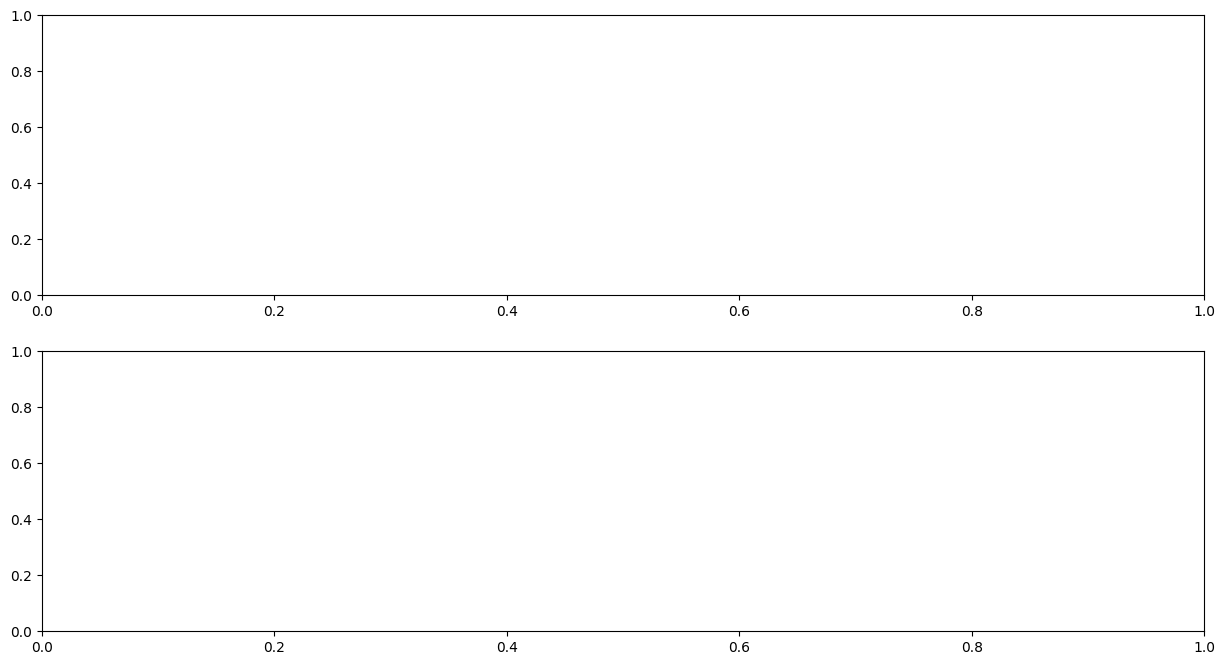

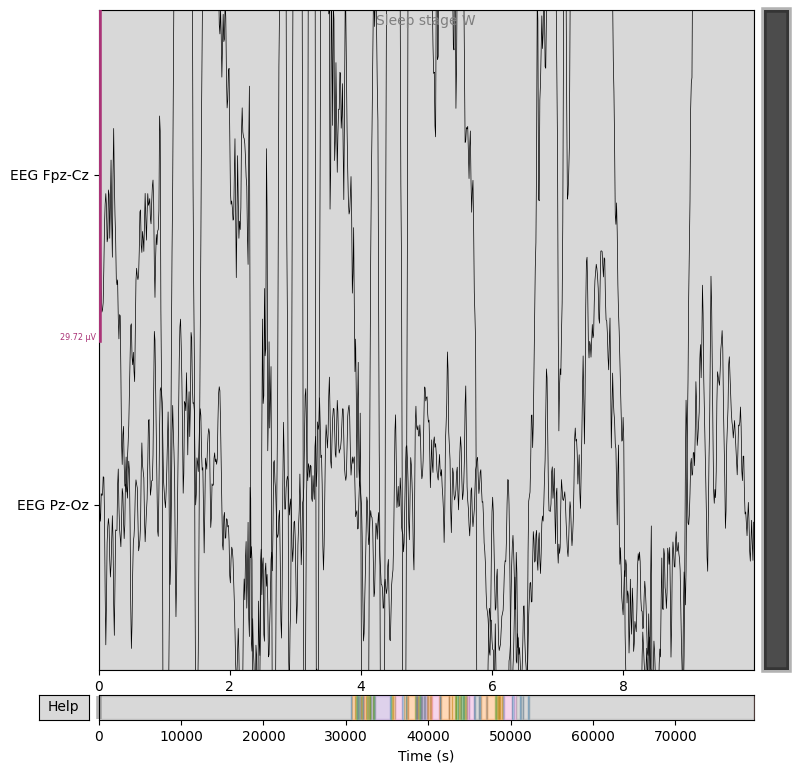

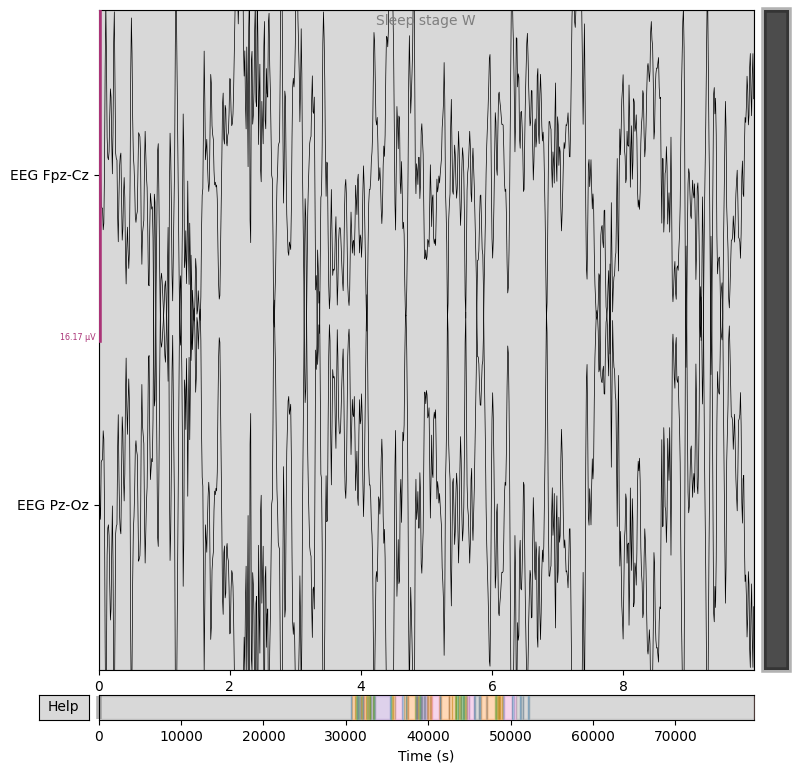

In [10]:
#比較
fig,axes=plt.subplots(2,1,figsize=(15,8))
DURATION=10
N_CHANNELS=2
#前
raw_filtered.plot(duration=DURATION,n_channels=N_CHANNELS,scalings='auto',title='ICA Before',show=False)
#後
raw_clean.plot(duration=10,n_channels=2,scalings='auto',title='ICA After',show=False)
plt.show()